# Proyecto Innovacien — 2. Análisis territorial

**Curso:** Código y Programación · Samsung Innovation Campus Chile 2026 — Cohort 2

## Pregunta de análisis

> **¿Cómo se distribuyen en Chile los registros de las tres especies invasoras
> que el modelo identifica —jabalí, liebre europea y rata gris— y en qué se
> diferencian sus patrones territoriales?**

La pregunta habla de *los registros* y no de *las especies* a propósito: los datos
disponibles describen dónde se ha observado, que no es lo mismo que dónde están.
Todo el notebook trabaja sobre esa distinción.

Trabajamos con las 49.165 ocurrencias que dejó el notebook 01, de tres especies:
**jabalí** (*Sus scrofa*), **liebre europea** (*Lepus europaeus*) y **rata gris**
(*Rattus norvegicus*).

## La restricción que ordena todo el análisis

El notebook 01 encontró que **el 98,2% de los registros proviene del monitoreo
con cámaras trampa de CONAF en áreas silvestres protegidas**, y que ese
programa no tiene *ni un* registro de rata gris.

Eso significa que la pregunta no se puede responder con un promedio global. Un
número como "3,5% de los registros son urbanos" no describe a las especies:
describe dónde CONAF instaló cámaras. Así que **cada resultado territorial de
este notebook va desagregado por fuente**, y donde eso no es posible, se declara.

## Preparación

In [1]:
import os
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

occ = pd.read_csv("data/procesado/ocurrencias.csv", low_memory=False)
occ["fecha"] = pd.to_datetime(occ["fecha"], errors="coerce")
occ["nombre_comun"] = occ["clase_modelo"].map(
    {"jabali": "Jabali", "liebre": "Liebre europea", "rata gris": "Rata gris"})

print(f"{len(occ):,} ocurrencias cargadas")
occ[["nombre_comun", "region", "entorno", "fuente", "anio"]].head(3)

49,165 ocurrencias cargadas


,nombre_comun,region,entorno,fuente,anio
0,Jabali,Araucania,Rural,Ciencia ciudadana (iNaturalist),2026.0
1,Jabali,Los Lagos,Rural,Ciencia ciudadana (iNaturalist),2026.0
2,Jabali,Araucania,Rural,Ciencia ciudadana (iNaturalist),2026.0


### Estilo de los gráficos

Los colores de especie no salen de la paleta natural de la marca (verdes y
terracotas). Esa paleta viste bien la interfaz, pero **no sirve para codificar
categorías**: sus verdes apagados caen bajo el piso de croma —se leen como
gris— y el par naranja/verde es exactamente el que la daltonía rojo-verde
vuelve indistinguible.

Los tres hues de abajo pasan las verificaciones de contraste y de separación
para daltonismo (deuteranopia, protanopia, tritanopia) en todos los pares. La
asignación es fija: cada especie conserva su color en todos los gráficos, así
que el color siempre significa lo mismo.

In [2]:
COLOR = {
    "Jabali":         "#EB6834",   # naranja
    "Liebre europea": "#2A78D6",   # azul
    "Rata gris":      "#1BAF7A",   # aqua
}
ORDEN = ["Jabali", "Liebre europea", "Rata gris"]

# Orden fijo de las fuentes, de mayor a menor peso en el conjunto. Se usa en
# TODOS los graficos: si el orden cambiara entre uno y otro, comparar paneles
# obligaria a releer las etiquetas cada vez.
FUENTES_ORD = ["Camara trampa (CONAF)", "Ciencia ciudadana (iNaturalist)",
               "Coleccion museologica", "Otros estudios"]

TINTA        = "#2B2B26"
TINTA_SUAVE  = "#6B6B63"
GRIS_REJILLA = "#DCDCD4"

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 10,
    "text.color": TINTA,
    "axes.labelcolor": TINTA,
    "axes.edgecolor": GRIS_REJILLA,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TINTA_SUAVE,
    "ytick.color": TINTA_SUAVE,
    "xtick.labelcolor": TINTA_SUAVE,
    "ytick.labelcolor": TINTA_SUAVE,
    "grid.color": GRIS_REJILLA,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def rejilla(ax, eje="y"):
    # Rejilla recesiva, siempre por detras de los datos.
    ax.grid(axis=eje, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)


print("Paleta fijada:", " · ".join(f"{k} {v}" for k, v in COLOR.items()))

Paleta fijada: Jabali #EB6834 · Liebre europea #2A78D6 · Rata gris #1BAF7A


---
# 1. Cuántos datos hay de cada especie, y de dónde vienen

Antes de cualquier mapa hay que dimensionar el material. La razón entre la
especie más y menos registrada es de **198 a 1**, así que el eje va en escala
logarítmica: en escala lineal las barras de la rata gris serían invisibles.
Los valores van etiquetados directamente para que la escala no engañe.

findfont: Failed to find font weight 600, now using 700.


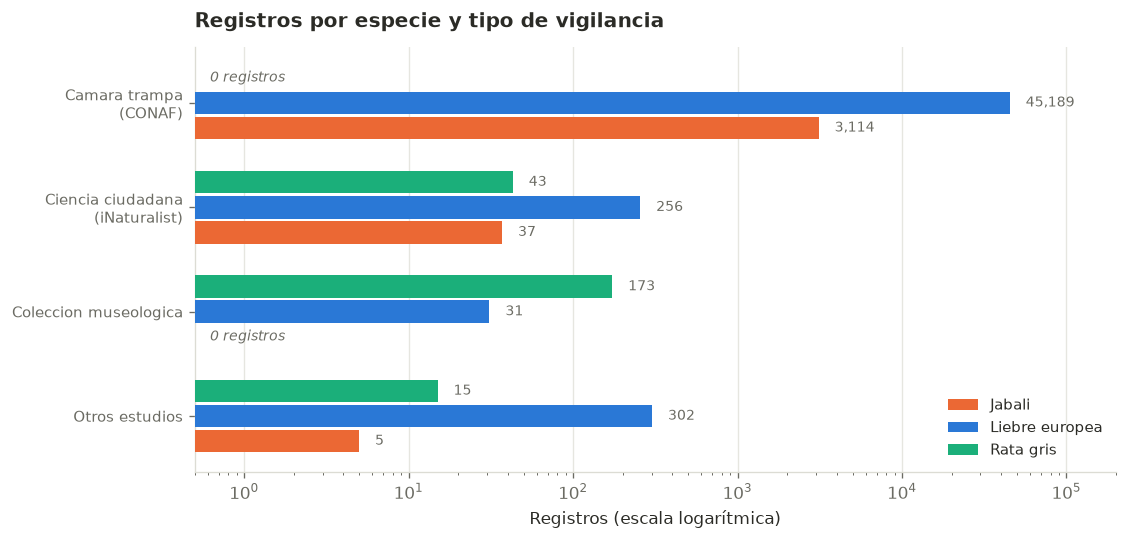

nombre_comun,Jabali,Liebre europea,Rata gris
fuente,,,
Otros estudios,5,302,15
Coleccion museologica,0,31,173
Ciencia ciudadana (iNaturalist),37,256,43
Camara trampa (CONAF),3114,45189,0


In [3]:
tab = (occ.pivot_table(index="fuente", columns="nombre_comun", values="gbif_id",
                       aggfunc="count", fill_value=0)
          .reindex(columns=ORDEN, fill_value=0)
          .reindex(FUENTES_ORD[::-1]))   # invertido: barh dibuja de abajo hacia arriba

fig, ax = plt.subplots(figsize=(9.5, 4.6))
alto, y = 0.24, np.arange(len(tab))

for i, esp in enumerate(ORDEN):
    v = tab[esp].to_numpy()
    pos = y + (i - 1) * alto
    ax.barh(pos, np.maximum(v, 0.5), height=alto * 0.9, color=COLOR[esp],
            label=esp, zorder=3)
    for yy, vv in zip(pos, v):
        if vv > 0:
            ax.text(vv * 1.25, yy, f"{vv:,}", va="center", ha="left",
                    fontsize=8.5, color=TINTA_SUAVE)
        else:
            ax.text(0.62, yy, "0 registros", va="center", ha="left",
                    fontsize=8.5, color=TINTA_SUAVE, style="italic")

ax.set_xscale("log")
ax.set_yticks(y, [t.replace(" (", "\n(") for t in tab.index], fontsize=9)
ax.set_xlim(0.5, 200_000)
ax.set_xlabel("Registros (escala logarítmica)")
ax.set_title("Registros por especie y tipo de vigilancia")
ax.legend(loc="lower right", ncol=1, fontsize=9)
rejilla(ax, "x")
plt.tight_layout()
plt.show()

tab

El gráfico deja ver de golpe las dos cosas que condicionan el análisis:

- **La barra de cámaras trampa domina por dos órdenes de magnitud.** 45.189
  liebres y 3.114 jabalíes salen de un solo programa institucional.
- **La rata gris no aparece en esa fuente.** Aparece solo en ciencia ciudadana,
  colecciones de museo y otros estudios, todos con volúmenes de dos cifras.

Cualquier lectura que sume las cuatro fuentes en un total va a estar describiendo,
en la práctica, el programa de CONAF.

---
# 2. ¿Qué tan urbana es cada especie? Depende de quién la observó

Esta es la comparación central. La misma pregunta —qué porcentaje de los
registros de una especie cae dentro de una zona urbana— respondida por separado
según la fuente.

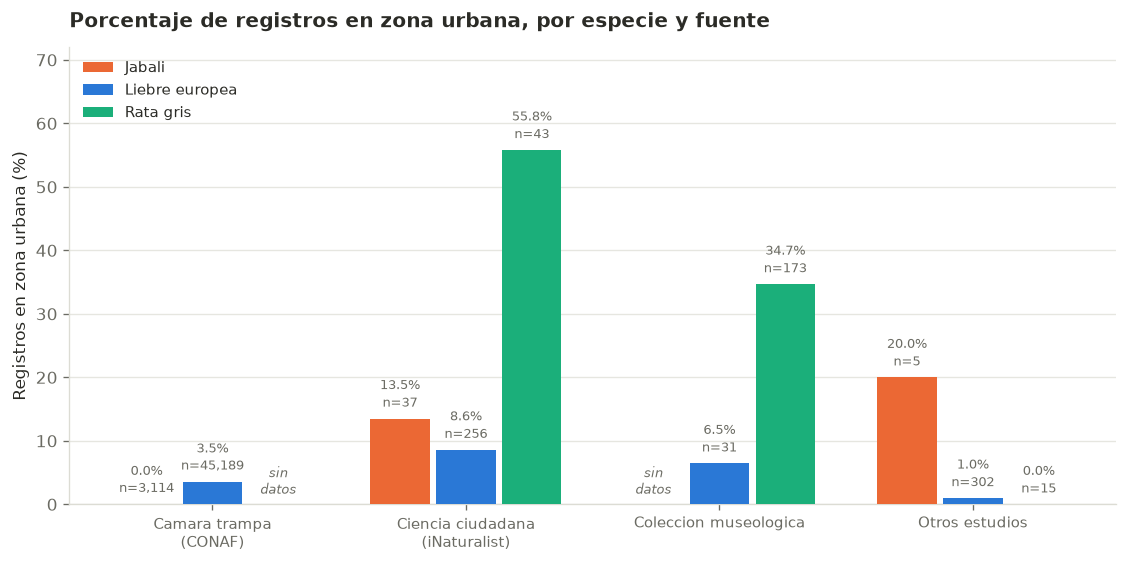

nombre_comun,Jabali,Liebre europea,Rata gris
fuente,,,
Camara trampa (CONAF),0.0,3.5,NaN
Ciencia ciudadana (iNaturalist),13.5,8.6,55.8
Coleccion museologica,NaN,6.5,34.7
Otros estudios,20.0,1.0,0.0


In [4]:
urb = (occ.pivot_table(index="fuente", columns="nombre_comun", values="entorno",
                       aggfunc=lambda s: 100 * (s == "Urbano").mean())
          .reindex(columns=ORDEN).reindex(FUENTES_ORD))
n = (occ.pivot_table(index="fuente", columns="nombre_comun", values="gbif_id",
                     aggfunc="count").reindex(columns=ORDEN).reindex(FUENTES_ORD))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ancho, x = 0.26, np.arange(len(urb))

for i, esp in enumerate(ORDEN):
    v = urb[esp].to_numpy(dtype=float)
    pos = x + (i - 1) * ancho
    ax.bar(pos, np.nan_to_num(v), width=ancho * 0.9, color=COLOR[esp],
           label=esp, zorder=3)
    # El porcentaje y su tamano de muestra van juntos, encima de la barra: dentro
    # de la barra el texto no cabe cuando el valor es bajo y choca con la cifra.
    for xx, vv, nn in zip(pos, v, n[esp].to_numpy()):
        if np.isnan(vv):
            ax.text(xx, 1.0, "sin\ndatos", ha="center", va="bottom", fontsize=7.5,
                    color=TINTA_SUAVE, style="italic")
        else:
            ax.text(xx, vv + 1.2, f"{vv:.1f}%\nn={int(nn):,}", ha="center",
                    va="bottom", fontsize=7.8, color=TINTA_SUAVE, linespacing=1.35)

ax.set_xticks(x, [t.replace(" (", "\n(") for t in urb.index], fontsize=9)
ax.set_ylabel("Registros en zona urbana (%)")
ax.set_ylim(0, 72)
ax.set_title("Porcentaje de registros en zona urbana, por especie y fuente")
ax.legend(loc="upper left", fontsize=9)
rejilla(ax, "y")
plt.tight_layout()
plt.show()

urb.round(1)

Tres resultados concretos:

1. **La rata gris es la única claramente urbana**: 55,8% de sus registros
   ciudadanos caen en ciudad, y 34,7% de los de museo. Es coherente con su
   biología —vive asociada a asentamientos humanos— y explica por qué las
   cámaras trampa de áreas protegidas no la ven nunca.

2. **El jabalí es rural en toda fuente con volumen suficiente**: 0,0% en cámaras
   trampa. El 13,5% y el 20% de las otras dos fuentes están calculados sobre 37 y
   5 registros respectivamente, así que no sostienen una conclusión.

3. **La liebre es rural de forma consistente** (1,0%–8,6%), y es la única especie
   donde las cuatro fuentes coinciden en el orden de magnitud. Es el resultado
   más confiable del gráfico, precisamente porque no depende de la fuente.

> **Lectura de los `n=`.** Los porcentajes de las columnas pequeñas son
> frágiles: 20% sobre 5 registros es un solo jabalí. Por eso cada barra lleva su
> tamaño de muestra encima; sin ese dato el gráfico invitaría a conclusiones que
> los datos no aguantan.

---
# 3. Distribución latitudinal: dónde está cada especie a lo largo de Chile

Chile tiene 4.300 km de norte a sur, así que la latitud es el eje natural. La
ponemos en el eje vertical para que el gráfico se lea como el mapa: Arica
arriba, Magallanes abajo.

Dos decisiones para que la comparación sea legítima:

- **Paneles separados por fuente** (*small multiples*) en vez de superponer todo.
  Cada panel es internamente comparable, y las diferencias *entre* paneles son
  justamente el sesgo que queremos exhibir.
- **El eje horizontal es porcentaje, no conteo.** Cada curva muestra qué
  proporción de los registros *de esa especie en esa fuente* cae en cada franja
  de 2°. Con conteos absolutos y un desbalance de 198:1, la curva de la liebre
  aplastaría a las otras dos y no se podrían comparar las formas. Normalizando,
  la pregunta que responde el gráfico es "¿a lo largo de qué latitudes se
  reparte esta especie?", que es la que nos interesa.

Las series con menos de 5 registros no se dibujan: con tan pocos puntos la
"forma" de una distribución no significa nada.

findfont: Failed to find font weight 600, now using 700.


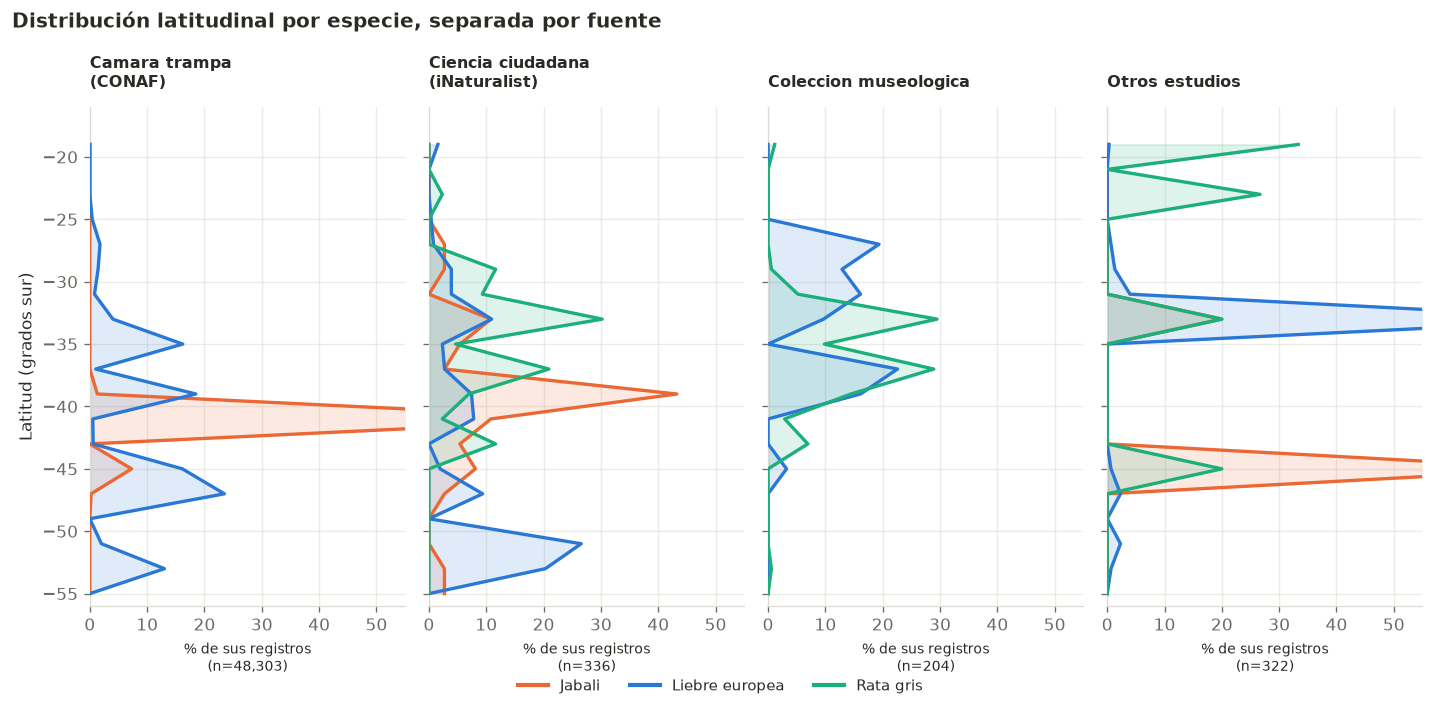

In [5]:
bins = np.arange(-56, -16, 2.0)
centros = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(1, 4, figsize=(12, 5.8), sharey=True, sharex=True)

for ax, f in zip(axes, FUENTES_ORD):
    sub = occ[occ["fuente"] == f]
    for esp in ORDEN:
        lats = sub.loc[sub["nombre_comun"] == esp, "lat"].dropna()
        if len(lats) < 5:          # con menos de 5 puntos la 'forma' no significa nada
            continue
        # Proporcion dentro de la propia especie-fuente, no conteo: asi la forma
        # de las curvas es comparable entre paneles pese al desbalance de 198:1.
        h = np.histogram(lats, bins=bins)[0] / len(lats) * 100
        ax.plot(h, centros, color=COLOR[esp], lw=2, label=esp, zorder=3)
        ax.fill_betweenx(centros, 0, h, color=COLOR[esp], alpha=0.14, zorder=2)

    ax.set_title(f.replace(" (", "\n("), fontsize=9.5)
    ax.set_xlabel(f"% de sus registros\n(n={len(sub):,})", fontsize=8.5)
    ax.grid(axis="both", alpha=0.55, zorder=0)
    ax.set_axisbelow(True)

# La latitud es negativa: -17 (Arica) arriba y -56 (Magallanes) abajo sale del
# orden natural del eje, sin invertirlo.
axes[0].set_ylim(-56, -16)
axes[0].set_xlim(0, 55)
axes[0].set_ylabel("Latitud (grados sur)")
axes[0].set_yticks(np.arange(-55, -15, 5))

manijas = [plt.Line2D([], [], color=COLOR[e], lw=2.5, label=e) for e in ORDEN]
fig.legend(handles=manijas, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Distribución latitudinal por especie, separada por fuente",
             x=0.008, ha="left", fontsize=12, fontweight="600")
plt.tight_layout()
plt.show()

### Lo que muestran los paneles

**El jabalí de las cámaras trampa está absurdamente concentrado:** el **91%** de
sus 3.114 registros cae en una única franja de 2°, en torno a −41°. Ninguna
especie se distribuye así en la naturaleza. Lo que ese pico describe es un
puñado de cámaras instaladas en una zona muy acotada, disparándose muchas veces.
Es el ejemplo más claro del notebook de por qué el volumen de registros no mide
presencia.

**La liebre cambia de latitud según quién la mire.** Es la misma especie, en
azul, en los cuatro paneles:

| Fuente | Pico latitudinal | Mediana |
|---|---|---|
| Cámaras trampa | −47° (23%) | −46,0° |
| Ciencia ciudadana | −51° (27%) | −47,1° |
| Colección museológica | −37° (23%) | −32,7° |
| Otros estudios | −33° (88%) | −33,7° |

Entre "cámaras trampa" y "otros estudios" hay **14 grados de diferencia** en la
mediana — del centro del país a la Patagonia. Es imposible que las dos describan
la misma realidad biológica; describen dos programas de observación distintos.

**La rata gris es la más consistente entre fuentes independientes:** pico en −33°
tanto en ciencia ciudadana (30%) como en colecciones de museo (29%). Que dos
fuentes que no comparten metodología ni época —una es iNaturalist desde 2009, la
otra especímenes desde 1907— coincidan en la misma franja latitudinal es el
indicio más fuerte de todo el análisis. Ese acuerdo es lo que convierte "la rata
gris está en la zona central" en una afirmación defendible, en vez de un
artefacto del muestreo.

In [6]:
lat = (occ.groupby(["nombre_comun", "fuente"])["lat"]
          .agg(["count", "median", "min", "max"]).round(2)
          .rename(columns={"count": "n", "median": "lat_mediana",
                           "min": "lat_norte", "max": "lat_sur"}))
lat.reindex(ORDEN, level=0)

n  lat_mediana  lat_norte  lat_sur
nombre_comun   fuente                                                                 
Jabali         Camara trampa (CONAF)             3114       -41.06     -46.06   -38.42
               Ciencia ciudadana (iNaturalist)     37       -39.40     -54.93   -27.35
               Otros estudios                       5       -44.37     -45.45   -33.44
Liebre europea Camara trampa (CONAF)            45189       -45.97     -53.44   -25.91
               Ciencia ciudadana (iNaturalist)    256       -47.11     -53.65   -18.19
               Coleccion museologica               31       -32.65     -45.48   -26.90
               Otros estudios                     302       -33.65     -53.66   -18.80
Rata gris      Ciencia ciudadana (iNaturalist)     43       -33.79     -43.13   -22.46
               Coleccion museologica              173       -36.54     -53.13   -18.49
               Otros estudios                      15       -22.43     -45.52   -18.42

---
# 4. El mapa: dónde se observó cada especie

Un plano lon/lat es, para Chile, un mapa razonable sin necesidad de shapefiles.
Otra vez con paneles por fuente, para que la geografía del muestreo quede a la
vista.

findfont: Failed to find font weight 600, now using 700.


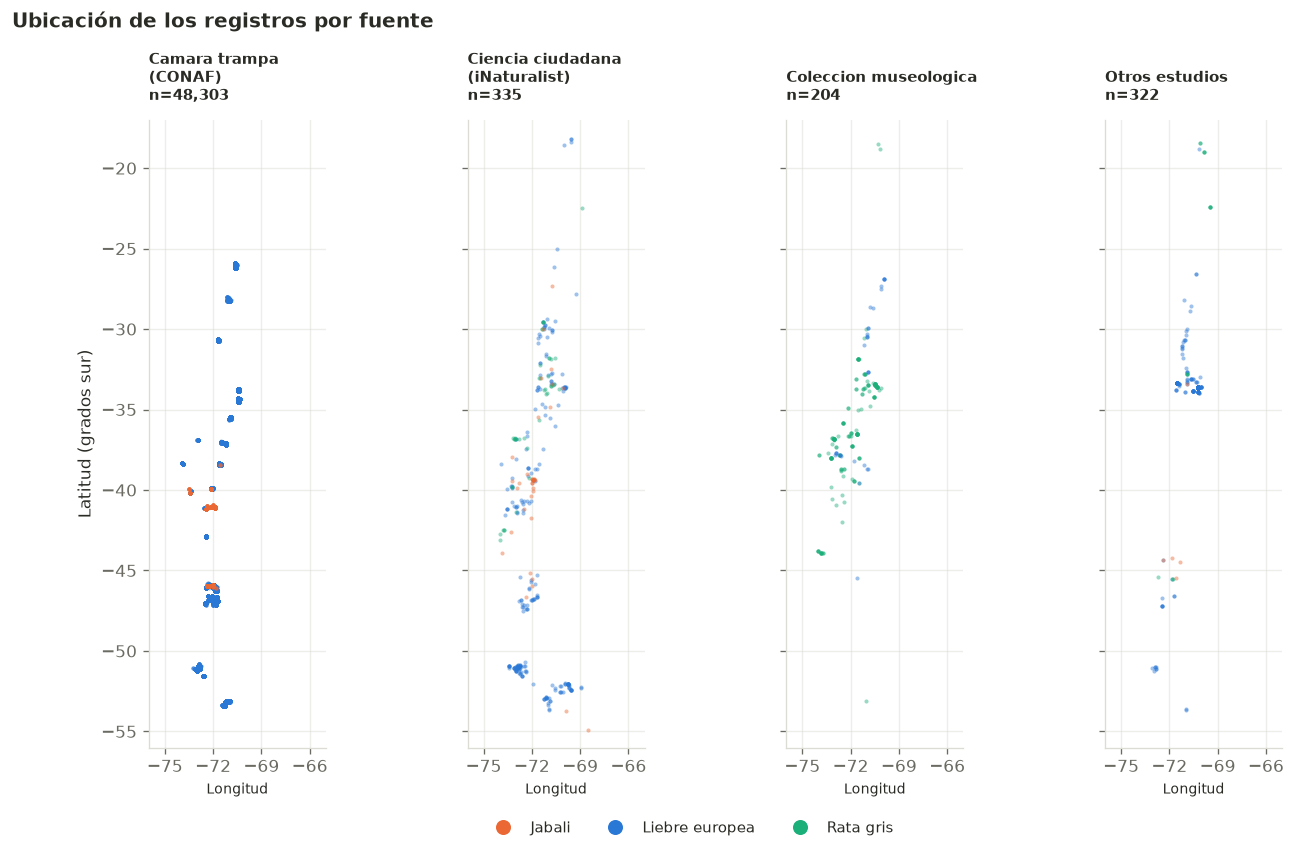

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(11.5, 7.2), sharex=True, sharey=True)

for ax, f in zip(axes, FUENTES_ORD):
    sub = occ[(occ["fuente"] == f) & (occ["territorio"] == "Continental")]
    # Se dibuja de la especie mas numerosa a la menos, para que los pocos puntos
    # de la rata gris queden encima de las masas de liebre y no se pierdan.
    for esp in sorted(ORDEN, key=lambda e: -(sub["nombre_comun"] == e).sum()):
        s = sub[sub["nombre_comun"] == esp]
        if s.empty:
            continue
        ax.scatter(s["lon"], s["lat"], s=6, color=COLOR[esp], alpha=0.45,
                   linewidths=0, label=esp, zorder=3)
    ax.set_title(f"{f.replace(' (', chr(10) + '(')}\nn={len(sub):,}", fontsize=9)
    ax.set_xlabel("Longitud", fontsize=8.5)
    ax.set_xticks([-75, -72, -69, -66])       # 4 marcas: con mas se solapan entre paneles
    ax.grid(alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_aspect("equal")                     # 1 grado de lat = 1 de lon: Chile no sale achatado

axes[0].set_ylabel("Latitud (grados sur)")
axes[0].set_xlim(-76, -65)
axes[0].set_ylim(-56, -17)                     # sin invertir: el norte ya queda arriba

manijas = [plt.Line2D([], [], marker="o", ls="", ms=8, color=COLOR[e], label=e)
           for e in ORDEN]
fig.legend(handles=manijas, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, 0.01))
fig.suptitle("Ubicación de los registros por fuente", x=0.008, ha="left",
             fontsize=12, fontweight="600")
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

El primer panel dibuja la red de cámaras trampa: bandas densas y alineadas en la
Patagonia y la Araucanía, con huecos completos en el norte. El segundo dibuja
dónde vive y camina la gente con un celular: la zona central y los alrededores
de las ciudades.

Ninguno de los dos es un mapa de las especies. Los dos juntos, leídos con
cuidado, es lo más cerca que estos datos permiten llegar.

---
# 5. Cobertura temporal

Cuándo se generó cada registro. Importa porque una serie temporal sobre estos
datos es fácil de malinterpretar como "aumento de la invasión".

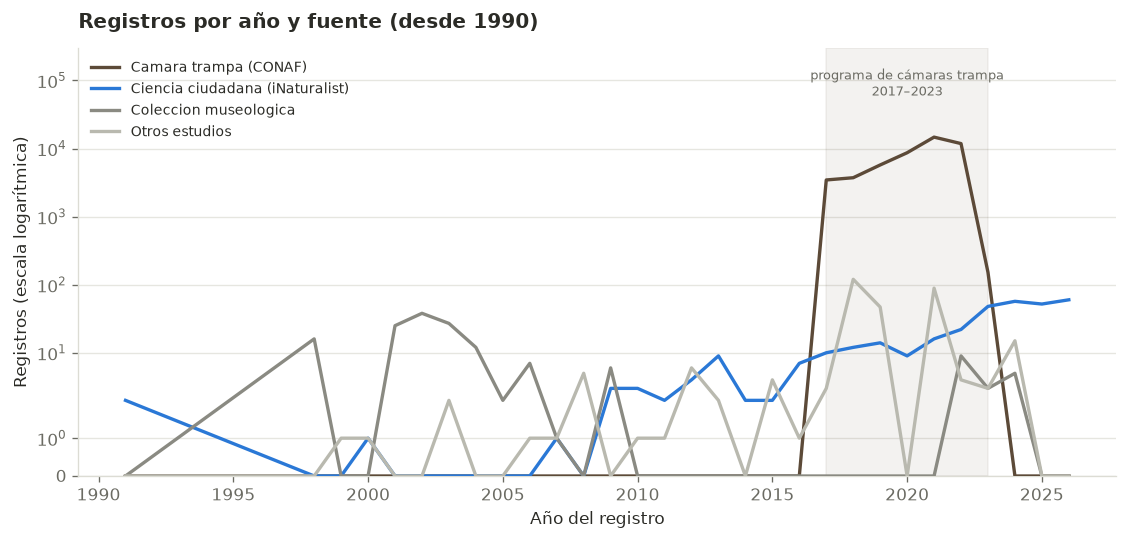

,min,max,count
fuente,,,
Camara trampa (CONAF),2017.0,2023.0,48303
Ciencia ciudadana (iNaturalist),1991.0,2026.0,336
Coleccion museologica,1907.0,2024.0,200
Otros estudios,1970.0,2024.0,311


In [8]:
serie = (occ[occ["tiene_anio"] & (occ["anio"] >= 1990)]
         .pivot_table(index="anio", columns="fuente", values="gbif_id",
                      aggfunc="count", fill_value=0)
         .reindex(columns=FUENTES_ORD, fill_value=0))

# Una sola escala, un solo eje: la comparacion es entre fuentes.
GRIS_FUENTE = {"Camara trampa (CONAF)": "#5C4A38",
               "Ciencia ciudadana (iNaturalist)": "#2A78D6",
               "Coleccion museologica": "#8A8A82",
               "Otros estudios": "#B9B9AF"}

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for f in FUENTES_ORD:
    ax.plot(serie.index, serie[f], lw=2, color=GRIS_FUENTE[f], label=f, zorder=3)

ax.set_yscale("symlog")
ax.set_ylim(0, 300_000)          # cabecera libre para que la anotacion no pise la curva
ax.set_xlabel("Año del registro")
ax.set_ylabel("Registros (escala logarítmica)")
ax.set_title("Registros por año y fuente (desde 1990)")
ax.legend(fontsize=8.5, loc="upper left")
rejilla(ax, "y")

# El periodo de CONAF explica casi toda la forma de la serie.
ax.axvspan(2017, 2023, color="#5C4A38", alpha=0.07, zorder=1)
ax.annotate("programa de cámaras trampa\n2017–2023", xy=(2020, 90_000),
            fontsize=8, color=TINTA_SUAVE, ha="center", va="center")
plt.tight_layout()
plt.show()

occ.groupby("fuente")["anio"].agg(["min", "max", "count"])

La serie está dominada por una ventana de siete años, 2017–2023, que es la
duración del programa de cámaras trampa. Fuera de esa ventana los volúmenes
caen a dos cifras.

**Por eso este notebook no incluye un análisis de tendencia.** Un gráfico de
"registros por año" sobre estos datos mostraría un pico enorme en 2017–2023 que
un lector interpretaría como una explosión poblacional, cuando lo único que
ocurrió fue que alguien instaló cámaras. Los datos no permiten separar cambio en
la especie de cambio en el esfuerzo de observación.

---
# 6. Regiones

Agregamos por **región** y no por comuna: el notebook 01 mostró que la comuna
asignada queda a 34 km de mediana del registro, así que a ese nivel la etiqueta
no es confiable.

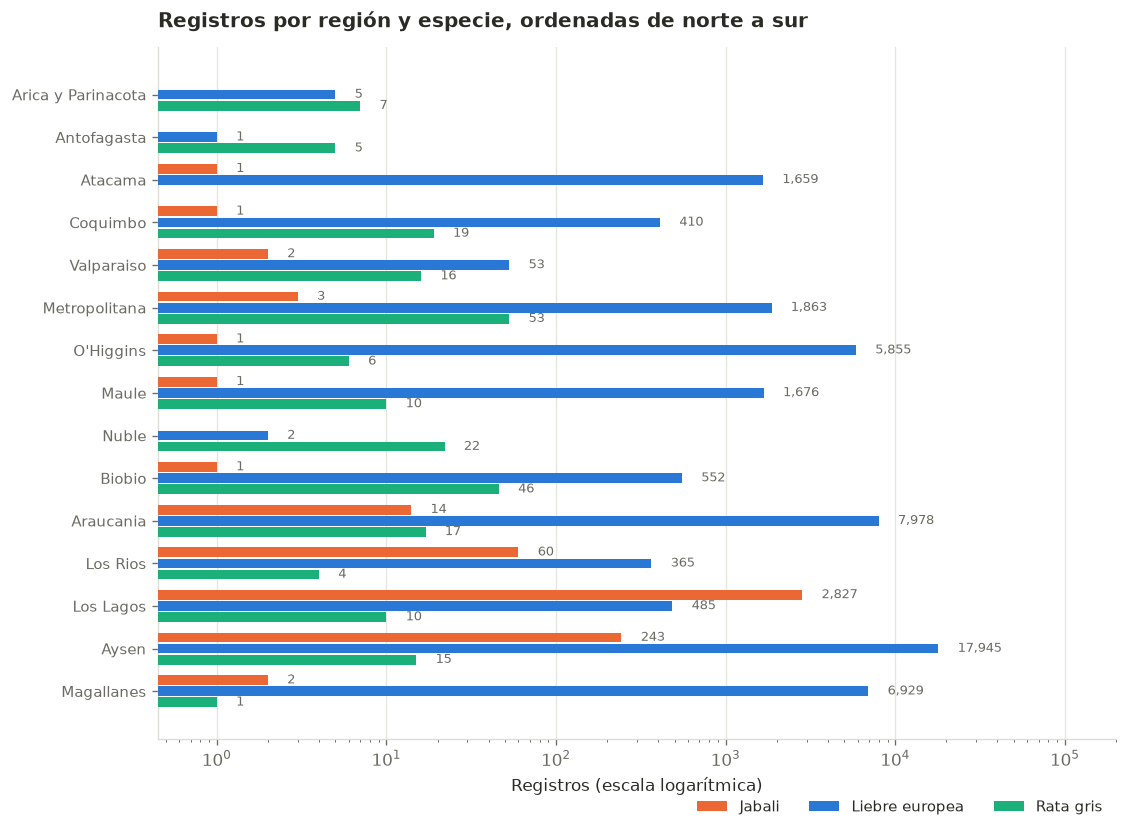

nombre_comun,Jabali,Liebre europea,Rata gris,total
region,,,,
Arica y Parinacota,0,5,7,12
Antofagasta,0,1,5,6
Atacama,1,1659,0,1660
Coquimbo,1,410,19,430
Valparaiso,2,53,16,71
Metropolitana,3,1863,53,1919
O'Higgins,1,5855,6,5862
Maule,1,1676,10,1687
Nuble,0,2,22,24


In [9]:
reg = (occ.pivot_table(index="region", columns="nombre_comun", values="gbif_id",
                       aggfunc="count", fill_value=0)
          .reindex(columns=ORDEN, fill_value=0))
reg["total"] = reg.sum(axis=1)
lat_reg = occ.groupby("region")["lat"].median()
reg = reg.loc[lat_reg.reindex(reg.index).sort_values(ascending=False).index]  # norte -> sur

# Barras AGRUPADAS, no apiladas. Apilar sobre un eje logaritmico seria
# incorrecto: en escala log la longitud de un segmento no es proporcional a su
# valor, asi que los tramos apilados no suman visualmente el total.
fig, ax = plt.subplots(figsize=(9.5, 7))
alto, y = 0.26, np.arange(len(reg))

for i, esp in enumerate(ORDEN):
    v = reg[esp].to_numpy(dtype=float)
    pos = y + (i - 1) * alto
    ax.barh(pos, np.maximum(v, 0.45), height=alto * 0.88, color=COLOR[esp],
            label=esp, zorder=3)
    for yy, vv in zip(pos, v):
        if vv > 0:
            ax.text(vv * 1.3, yy, f"{int(vv):,}", va="center", ha="left",
                    fontsize=7.5, color=TINTA_SUAVE)

ax.set_yticks(y, reg.index, fontsize=9)
ax.invert_yaxis()                     # eje categorico: indice 0 (norte) arriba
ax.set_xscale("log")
ax.set_xlim(0.45, 200_000)
ax.set_xlabel("Registros (escala logarítmica)")
ax.set_title("Registros por región y especie, ordenadas de norte a sur")
ax.legend(fontsize=9, loc="lower right", bbox_to_anchor=(1.0, -0.13), ncol=3)
rejilla(ax, "x")
plt.tight_layout()
plt.show()

reg

Aysén concentra la mayor parte de los registros, seguida por Araucanía y
Magallanes — el mapa de las cámaras trampa otra vez. La rata gris, en cambio,
aparece repartida en 14 regiones con volúmenes bajos, incluyendo el norte, donde
las otras dos fuentes casi no llegan.

Nota: dos regiones del diccionario no tienen ni un registro de las tres especies,
por lo que no aparecen en la tabla.

---
# 7. Respuesta a la pregunta de análisis

> **¿Cómo se distribuyen en Chile los registros de las tres especies invasoras
> que el modelo identifica, y en qué se diferencian sus patrones territoriales?**

**Sí hay tres patrones distintos, y el contraste principal es urbano/rural.**

| | Jabalí | Liebre europea | Rata gris |
|---|---|---|---|
| **Registros** | 3.156 | 45.778 | 231 |
| **Patrón** | Rural, sur del país | Rural, muy amplio | **Urbana**, zona central |
| **% urbano (ciencia ciudadana)** | 13,5% *(n=37)* | 8,6% *(n=256)* | **55,8%** *(n=43)* |
| **Latitud mediana** | −41,1° | −46,0° | −35,8° |
| **Regiones** | 12 | 15 | 14 |
| **Confianza del resultado** | Media | **Alta** | Media-baja |

**El criterio que usamos para decidir qué creer.** Con un 98% de los datos
proveniente de una sola fuente sesgada, no sirve preguntarse "¿qué dicen los
datos?" sino **"¿coinciden fuentes que no comparten metodología?"**. Cuando
iNaturalist (ciencia ciudadana, 2009–2026) y las colecciones museológicas
(especímenes, 1907–2022) apuntan a lo mismo, el resultado es creíble: no hay un
mecanismo común que las sesgue igual. Cuando solo lo dice CONAF, es una
propiedad del programa de cámaras.

**Lo que sostienen los datos:**

1. **La rata gris ocupa un nicho territorial distinto al de las otras dos.** Es
   la única con presencia urbana mayoritaria (55,8%), la única concentrada en la
   zona central, y la única invisible al monitoreo en áreas protegidas. Y pasa el
   test de concordancia: ciencia ciudadana y museos coinciden en el pico de −33°
   (30% y 29%) siendo fuentes independientes. **Es la conclusión más sólida del
   análisis**, a pesar de tener solo 231 registros.

2. **La liebre europea es la más extendida geográficamente**: 15 regiones, y las
   cuatro fuentes concuerdan en que es rural (1,0%–8,6% urbano). Pero su *patrón
   latitudinal* no es concluyente: la mediana varía 14° entre fuentes.

3. **El jabalí es rural y austral**, aunque es el caso más frágil: el 91% de sus
   registros sale de una sola franja de 2° monitoreada por cámaras trampa. Que no
   aparezca en el norte no prueba que no esté; prueba que ahí no hay cámaras.

**Lo que los datos NO permiten afirmar:**

- **Abundancia.** 45.778 registros de liebre contra 231 de rata gris no dicen
  que haya 198 veces más liebres. Dicen que el programa que aporta el 98% de los
  datos apunta a hábitats de liebre y no a hábitats de rata.
- **Tendencia temporal.** La ventana 2017–2023 es la del programa de cámaras, no
  la de la invasión.
- **Ausencia.** Que no haya registros de jabalí en el norte no prueba que no
  haya jabalíes en el norte; puede que no haya nadie observando.

## Implicación para el producto

El análisis dice algo directamente útil para la app: **las tres especies exigen
canales de vigilancia distintos**. La rata gris es la que un ciudadano
efectivamente se va a encontrar y fotografiar en una ciudad — y es justo la que
el monitoreo institucional no cubre. Ahí es donde una app de reporte ciudadano
aporta información que hoy no existe, en vez de duplicar lo que las cámaras
trampa ya registran.

Es también la especie con menos datos de las tres (231 registros, apenas 43 de
ciencia ciudadana), así que es la que más se beneficiaría de cada foto nueva.